# Dunnhumby: The Complete Journey | 06 Basket Analysis

Which products are bought together in the same trip, and which of those links are strong enough to act on (cross-merchandising, bundles, cross-category offers).

The whole market basket analysis is done in SQL with a self-join, instead of a library such as mlxtend. That makes every metric transparent and shows exactly what support, confidence and lift mean.

**Level of analysis:** commodity (for example `SOFT DRINKS`, `CHEESE`), not individual product. There are over 90,000 products, so almost every product pair would be too rare to measure reliably.

**Rules carried over from the audit:** merchandise lines only, weeks 16 to 101.

**Outputs:** `data/processed/commodity_pairs.parquet` and 1 chart in `outputs/figures/` (`06_*.png`).

In [1]:
!pip -q install -U duckdb
from google.colab import drive
from pathlib import Path
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
drive.mount('/content/drive')
PROJ = Path('/content/drive/MyDrive/Dunnhumby Project')
DATA, FIG = PROJ/'data/processed', PROJ/'outputs/figures'
con = duckdb.connect()
for f in sorted(DATA.glob('*.parquet')): con.execute(f"CREATE OR REPLACE VIEW {f.stem} AS SELECT * FROM '{f}'")
q = lambda s: con.sql(s).df()
pd.set_option('display.max_columns', 50, 'display.width', 200)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 65.6 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
con.execute("""
CREATE OR REPLACE VIEW sales AS
SELECT f.*, p.department, p.commodity
FROM fact_sales f
JOIN dim_product p ON p.product_id = f.product_id
WHERE NOT f.is_nonmerch AND NOT f.is_zero_line AND f.week_no BETWEEN 16 AND 101
""");

## 1. Metrics used

For two commodities A and B, over all N baskets:

| Metric | Formula | Meaning |
|---|---|---|
| Support | baskets with A and B / N | how common the pair is |
| Confidence A → B | baskets with A and B / baskets with A | chance a basket with A also has B |
| Lift | support(A and B) / (support(A) × support(B)) | how much more often they appear together than if they were unrelated (1 = no link) |
| Leverage | support(A and B) − support(A) × support(B) | the extra share of all baskets that contain the pair because of the link |

Lift shows **how strong** a link is, and leverage shows **how much it matters**. A rare pair can have a huge lift but affect very few baskets, so both are reported.

**Thresholds:** a commodity must appear in at least 1% of baskets, and a pair in at least 0.2%. With about 230,000 baskets, that means every reported pair is seen in several hundred baskets, so the relative sampling error of its lift is only around 5%.

In [3]:
MIN_ITEM, MIN_PAIR = 0.01, 0.002

## 2. Basket shape
Pairs only exist in baskets with at least two commodities, so this shows how much of the data the analysis actually covers.

In [4]:
con.execute("""
CREATE OR REPLACE TABLE bc AS SELECT DISTINCT basket_id, commodity FROM sales;
CREATE OR REPLACE TABLE item_dept AS SELECT commodity, MODE(department) AS department FROM sales GROUP BY commodity;
""");
q("""
WITH b AS (SELECT basket_id, COUNT(*) AS commodities FROM bc GROUP BY basket_id)
SELECT COUNT(*) AS baskets,
       ROUND(AVG(commodities), 1) AS avg_commodities_per_basket,
       MEDIAN(commodities) AS median_commodities_per_basket,
       ROUND(100.0 * SUM(CASE WHEN commodities >= 2 THEN 1 ELSE 0 END) / COUNT(*), 1) AS baskets_with_2plus_pct,
       (SELECT COUNT(DISTINCT commodity) FROM bc) AS commodities
FROM b
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,baskets,avg_commodities_per_basket,median_commodities_per_basket,baskets_with_2plus_pct,commodities
0,230892,7.5,4.0,82.2,303


## 3. Commodity pairs
1. `items` keeps commodities that appear in at least 1% of baskets.
2. The self-join `bc a JOIN bc b ON same basket AND a.commodity < b.commodity` lists every pair in every basket exactly once. The `<` stops each pair being counted twice (A-B and B-A) and stops a commodity pairing with itself.
3. The final select turns the counts into support, confidence, lift and leverage.

In [5]:
con.execute(f"""
CREATE OR REPLACE TABLE items AS
SELECT commodity, COUNT(*) AS n_baskets
FROM bc
GROUP BY commodity
HAVING COUNT(*) >= {MIN_ITEM} * (SELECT COUNT(DISTINCT basket_id) FROM bc);

CREATE OR REPLACE TABLE pairs AS
WITH n AS (SELECT COUNT(DISTINCT basket_id) AS n FROM bc),
p AS (
  SELECT a.commodity AS item_a, b.commodity AS item_b, COUNT(*) AS n_ab
  FROM bc a
  JOIN bc b ON b.basket_id = a.basket_id AND a.commodity < b.commodity
  WHERE a.commodity IN (SELECT commodity FROM items) AND b.commodity IN (SELECT commodity FROM items)
  GROUP BY 1, 2
)
SELECT p.item_a, da.department AS dept_a, p.item_b, db.department AS dept_b, p.n_ab,
       1.0 * p.n_ab / n.n AS support,
       1.0 * p.n_ab / ia.n_baskets AS conf_a_to_b,
       1.0 * p.n_ab / ib.n_baskets AS conf_b_to_a,
       1.0 * p.n_ab * n.n / (1.0 * ia.n_baskets * ib.n_baskets) AS lift,
       1.0 * p.n_ab / n.n - (1.0 * ia.n_baskets / n.n) * (1.0 * ib.n_baskets / n.n) AS leverage
FROM p
JOIN items ia ON ia.commodity = p.item_a
JOIN items ib ON ib.commodity = p.item_b
JOIN item_dept da ON da.commodity = p.item_a
JOIN item_dept db ON db.commodity = p.item_b
CROSS JOIN n
WHERE p.n_ab >= {MIN_PAIR} * n.n;
""");
q("SELECT (SELECT COUNT(*) FROM items) AS frequent_commodities, COUNT(*) AS pairs_kept, SUM(CASE WHEN lift > 1 THEN 1 ELSE 0 END) AS pairs_with_lift_above_1 FROM pairs")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,frequent_commodities,pairs_kept,pairs_with_lift_above_1
0,155,6499,6428.0


### Strongest links (highest lift)

In [6]:
show = lambda order, where='TRUE': q(f"""
SELECT item_a, dept_a, item_b, dept_b, n_ab AS baskets, ROUND(100 * support, 2) AS support_pct,
       ROUND(100 * conf_a_to_b, 1) AS conf_a_to_b_pct, ROUND(100 * conf_b_to_a, 1) AS conf_b_to_a_pct,
       ROUND(lift, 2) AS lift, ROUND(100 * leverage, 3) AS leverage_pct
FROM pairs
WHERE {where}
ORDER BY {order} DESC
LIMIT 15
""")
show('lift')

,item_a,dept_a,item_b,dept_b,baskets,support_pct,conf_a_to_b_pct,conf_b_to_a_pct,lift,leverage_pct
0,CAT FOOD,GROCERY,CAT LITTER,GROCERY,1185,0.51,19.4,43.3,16.40,0.482
1,BABY FOODS,DRUG GM,INFANT FORMULA,DRUG GM,669,0.29,17.1,27.8,16.40,0.272
2,BABY HBC,DRUG GM,DIAPERS & DISPOSABLES,DRUG GM,1005,0.44,27.4,23.9,15.03,0.406
3,LAUNDRY ADDITIVES,GROCERY,LAUNDRY DETERGENTS,GROCERY,1731,0.75,42.4,22.2,12.55,0.690
4,BROOMS AND MOPS,DRUG GM,HOUSEHOLD CLEANG NEEDS,GROCERY,950,0.41,34.2,13.9,11.56,0.376
5,BLEACH,GROCERY,LAUNDRY ADDITIVES,GROCERY,646,0.28,19.9,15.8,11.23,0.255
6,DEODORANTS,DRUG GM,SHAVING CARE PRODUCTS,DRUG GM,563,0.24,14.5,18.5,10.99,0.222
7,BLEACH,GROCERY,LAUNDRY DETERGENTS,GROCERY,1171,0.51,36.0,15.0,10.67,0.460
8,DOG FOODS,GROCERY,PET CARE SUPPLIES,GROCERY,697,0.30,10.5,29.9,10.42,0.273
9,DRY NOODLES/PASTA,GROCERY,PASTA SAUCE,GROCERY,5940,2.57,45.6,54.7,9.70,2.307


### Links that matter most (highest leverage)
These pairs add the most baskets above what chance would give. They are usually big everyday categories, where even a moderate lift touches a large share of trips.

In [7]:
show('leverage')

,item_a,dept_a,item_b,dept_b,baskets,support_pct,conf_a_to_b_pct,conf_b_to_a_pct,lift,leverage_pct
0,BAKED BREAD/BUNS/ROLLS,GROCERY,FLUID MILK PRODUCTS,GROCERY,28791,12.47,51.7,44.9,1.86,5.760
1,BAKED BREAD/BUNS/ROLLS,GROCERY,CHEESE,GROCERY,22232,9.63,39.9,51.0,2.11,5.075
2,CHEESE,GROCERY,FLUID MILK PRODUCTS,GROCERY,22894,9.92,52.6,35.7,1.89,4.671
3,BAKED BREAD/BUNS/ROLLS,GROCERY,BEEF,MEAT,17342,7.51,31.1,51.3,2.12,3.976
4,COLD CEREAL,GROCERY,FLUID MILK PRODUCTS,GROCERY,15568,6.74,67.0,24.3,2.41,3.946
5,EGGS,GROCERY,FLUID MILK PRODUCTS,GROCERY,16109,6.98,62.2,25.1,2.24,3.858
6,BAG SNACKS,GROCERY,BAKED BREAD/BUNS/ROLLS,GROCERY,18096,7.84,46.7,32.5,1.94,3.789
7,BEEF,MEAT,CHEESE,GROCERY,14713,6.37,43.5,33.8,2.31,3.610
8,FLUID MILK PRODUCTS,GROCERY,TROPICAL FRUIT,PRODUCE,16522,7.16,25.7,55.2,1.99,3.554
9,BAG SNACKS,GROCERY,CHEESE,GROCERY,15334,6.64,39.6,35.2,2.10,3.477


### Cross-department links
Pairs from different departments are the most useful for the store: they suggest placing products near each other, or cross-category offers, which a single-department manager would not plan on their own.

In [8]:
show('lift', 'dept_a <> dept_b')

,item_a,dept_a,item_b,dept_b,baskets,support_pct,conf_a_to_b_pct,conf_b_to_a_pct,lift,leverage_pct
0,BROOMS AND MOPS,DRUG GM,HOUSEHOLD CLEANG NEEDS,GROCERY,950,0.41,34.2,13.9,11.56,0.376
1,BROOMS AND MOPS,DRUG GM,DISHWASH DETERGENTS,GROCERY,556,0.24,20.0,9.6,8.01,0.211
2,ORGANICS FRUIT & VEGETABLES,PRODUCE,REFRIGERATED,NUTRITION,716,0.31,14.5,15.1,7.04,0.266
3,HAIR CARE PRODUCTS,DRUG GM,MAKEUP AND TREATMENT,COSMETICS,741,0.32,10.1,20.4,6.40,0.271
4,SEAFOOD - FROZEN,SEAFOOD-PCKGD,SEAFOOD-FRESH,SEAFOOD,615,0.27,8.8,18.3,6.07,0.222
5,FROZEN MEAT,MEAT-PCKGD,FRZN POTATOES,GROCERY,1404,0.61,18.5,18.6,5.65,0.500
6,DRIED FRUIT,NUTRITION,FRUIT - SHELF STABLE,GROCERY,825,0.36,29.2,6.7,5.45,0.292
7,BROOMS AND MOPS,DRUG GM,LAUNDRY DETERGENTS,GROCERY,497,0.22,17.9,6.4,5.30,0.175
8,HOUSEHOLD CLEANG NEEDS,GROCERY,SOAP - LIQUID & BAR,DRUG GM,824,0.36,12.1,15.2,5.15,0.288
9,LAUNDRY ADDITIVES,GROCERY,SOAP - LIQUID & BAR,DRUG GM,490,0.21,12.0,9.0,5.11,0.171


## 4. Department co-purchase map
The same logic at department level, for departments in at least 2% of baskets. The colour shows log2(lift): red means the two departments are bought together more often than chance, blue less often.

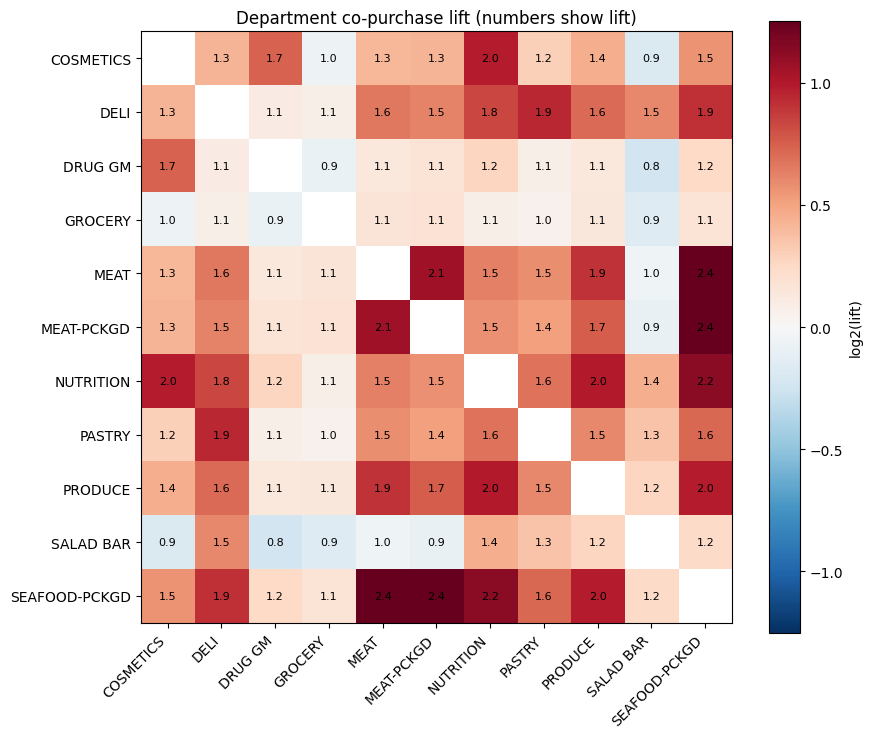

,dept_a,dept_b,lift
30,MEAT,SEAFOOD-PCKGD,2.38
19,MEAT-PCKGD,SEAFOOD-PCKGD,2.37
38,NUTRITION,SEAFOOD-PCKGD,2.20
27,MEAT,MEAT-PCKGD,2.09
14,NUTRITION,PRODUCE,1.99
28,PRODUCE,SEAFOOD-PCKGD,1.98
50,COSMETICS,NUTRITION,1.97
36,DELI,PASTRY,1.92
29,DELI,SEAFOOD-PCKGD,1.88
13,MEAT,PRODUCE,1.88


In [9]:
dl = q("""
WITH bd AS (SELECT DISTINCT basket_id, department FROM sales),
n AS (SELECT COUNT(DISTINCT basket_id) AS n FROM bd),
d AS (SELECT department, COUNT(*) AS n_d FROM bd GROUP BY department HAVING COUNT(*) >= 0.02 * (SELECT n FROM n)),
p AS (
  SELECT a.department AS dept_a, b.department AS dept_b, COUNT(*) AS n_ab
  FROM bd a
  JOIN bd b ON b.basket_id = a.basket_id AND a.department < b.department
  WHERE a.department IN (SELECT department FROM d) AND b.department IN (SELECT department FROM d)
  GROUP BY 1, 2
)
SELECT p.dept_a, p.dept_b, 1.0 * p.n_ab * n.n / (1.0 * da.n_d * db.n_d) AS lift
FROM p
JOIN d da ON da.department = p.dept_a
JOIN d db ON db.department = p.dept_b
CROSS JOIN n
""")
m = pd.concat([dl, dl.rename(columns={'dept_a': 'dept_b', 'dept_b': 'dept_a'})]).pivot(index='dept_a', columns='dept_b', values='lift')
v = np.log2(m)
lim = np.nanmax(np.abs(v.values))
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(v, cmap='RdBu_r', vmin=-lim, vmax=lim)
ax.set_xticks(range(len(v.columns)), v.columns, rotation=45, ha='right')
ax.set_yticks(range(len(v.index)), v.index)
for i in range(len(v.index)):
    for j in range(len(v.columns)):
        if not np.isnan(m.values[i, j]): ax.text(j, i, f'{m.values[i, j]:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='log2(lift)')
ax.set_title('Department co-purchase lift (numbers show lift)')
plt.tight_layout(); plt.savefig(FIG/'06_department_lift.png', dpi=150); plt.show()
dl.sort_values('lift', ascending=False).head(10).round(2)

## 5. Save
All kept commodity pairs with their metrics, for the Power BI dashboard.

In [10]:
con.execute(f"COPY pairs TO '{DATA}/commodity_pairs.parquet' (FORMAT PARQUET)")
q(f"SELECT COUNT(*) AS pairs FROM '{DATA}/commodity_pairs.parquet'")

,pairs
0,6499


## Findings

1. **Baskets are big enough for pair analysis.** The 230,892 baskets hold 7.5 commodities on average (median 4), and 82.2% contain at least two. 155 commodities pass the 1% threshold and 6,499 pairs pass the 0.2% threshold.
2. **Almost every pair has lift above 1 (6,428 of 6,499).** This is mostly a basket-size effect: big stock-up trips contain many commodities at once, so any two common items appear together more than chance would predict. A lift of about 2 is therefore the normal level for everyday items, and only pairs well above that show a genuine link.
3. **The strongest links are need-based complements.** Cat food and cat litter (lift 16.4), baby foods and infant formula (16.4), baby care and diapers (15.0), laundry additives and detergents (12.6), and brooms or mops with household cleaning products (11.6). Pasta and pasta sauce (lift 9.7, 5,940 baskets) and deli cheeses with deli meats (lift 9.2, 6,603 baskets) are strong links that also cover a large number of trips.
4. **The pairs that touch the most trips are staples.** Bread and milk appear together in 12.5% of all baskets (lift 1.86), followed by bread and cheese, and cheese and milk. Cereal buyers take milk in 67% of their baskets. These pairs matter because of volume, not because the link is unusual.
5. **Cross-department links show what separate department plans miss.** Brooms and mops (Drug GM) with household cleaning products (Grocery, lift 11.6), organic produce with refrigerated nutrition products (7.0), hair care with makeup (6.4), frozen with fresh seafood (6.1), frozen meat with frozen potatoes (5.7, 1,404 baskets), and hot dogs with shelf-stable meat (4.8, 2,653 baskets).
6. **Fresh and health departments form a cluster.** At department level, packaged seafood is most strongly linked with meat (2.38), packaged meat (2.37) and nutrition (2.20). Nutrition is linked with produce (1.99) and cosmetics (1.97). Nutrition, produce and fresh seafood were among the fastest growing departments in notebook 03 (13.1%, 9.9% and 15.2% per household), while packaged seafood was flat (-1.1%).
7. **Confidence is often one-sided.** 45.6% of pasta baskets include sauce, while 54.7% of sauce baskets include pasta, and 63% of deli cheese baskets include deli meats against 42% the other way. The weaker direction shows which group of shoppers still has room to add the second item.

**Limitations:** co-purchase is not causation, and a strong lift does not prove that promoting one item will sell the other. Commodity level also hides brand and size differences.

## Recommendations
1. **Place cross-department complements together.** Cleaning tools next to cleaning chemicals, hair care next to makeup, and frozen meat next to frozen potatoes. These links cross department boundaries, so they are exactly the ones a single-department layout misses.
2. **Target the weaker direction of strong pairs instead of discounting both items.** Most pasta sauce buyers already buy pasta. Offering sauce to the pasta buyers who do not yet take it reaches new sales without subsidising purchases that already happen.
3. **Use life-stage and pet links for personalised offers.** A household buying infant formula is a very likely diaper buyer, and a cat food buyer a likely litter buyer. These signals identify baby and pet households for targeted offers without needing demographic data, which only 32% of households have.
4. **Do not bundle-discount staples.** Bread, milk and cheese are bought together anyway. They work better as traffic drivers than as discounted bundles.
5. **Build a fresh and health zone.** Nutrition and produce are bought together and are growing faster than the store. Placing them near each other connects the strongest growth trend with a strong co-purchase link. Packaged seafood is flat despite strong links with meat, so offering it to meat buyers is a cheap test of whether those links can restart growth. Fresh seafood reaches only 32% of households, which leaves room to grow.
6. **Test before rolling out.** Each layout or offer change should run in a few stores first, with matched stores as a comparison, because co-purchase shows association only.